IMOPORTING LIBRARIES & DATASET

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
import kagglehub
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
print("Path to dataset files:", path)

df = pd.read_csv(path + "/diabetes.csv")

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Path to dataset files: /kaggle/input/pima-indians-diabetes-database


**SAVING LIBRARIES VERSION FOR DEPLOYMENT SYNC**

In [ ]:
print("numpy: ", np.__version__)
print("pandas: ", pd.__version__)
print("seaborn: ", sns.__version__)
print("sklearn: ", sns.__version__)

numpy:  2.0.2
pandas:  2.2.2
seaborn:  0.13.2
sklearn:  0.13.2


**DATA OVERVIEW**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
print ("Shape: ", df.shape)
df.head(3)

Shape:  (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


**DATA PRE PROCESSING**

In [ ]:
# For the below columns there is no such value as '0' therefore we will replace them with null

df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] = df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].replace(0, np.nan)
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:

# The whole idea is to replace the null values with average

def median_target(var):
    temp = df[df[var].notnull()]
    temp = temp[[var, 'Outcome']].groupby(['Outcome'])[[var]].median().reset_index()
    return temp

median_target("Insulin")



# INSULIN COLUMN


df.loc[
    (df['Outcome'] == 0) & (df['Insulin'].isna()),
    'Insulin'
] = 102.5

df.loc[
    (df['Outcome'] == 1) & (df['Insulin'].isna()),
    'Insulin'
] = 169.5


# GLUCOSE COLUMN

median_target('Glucose')


df.loc[
    (df['Outcome'] == 0) & (df['Glucose'].isna()),
    'Glucose'
] = 107.0

df.loc[
    (df['Outcome'] == 1) & (df['Glucose'].isna()),
    'Glucose'
] = 140.0


# BLOOD PRESSURE

median_target('BloodPressure')
df.loc[
    (df['Outcome'] == 0) & (df['BloodPressure'].isna()),
    'BloodPressure'
] = 70.0

df.loc[
    (df['Outcome'] == 1) & (df['BloodPressure'].isna()),
    'BloodPressure'
] = 74.5



# SKIN THICKNESS


median_target('SkinThickness')

df.loc[
    (df['Outcome'] == 0) & (df['SkinThickness'].isna()),
    'SkinThickness'
] = 27.0

df.loc[
    (df['Outcome'] == 1) & (df['SkinThickness'].isna()),
    'SkinThickness'
] = 32.0


# BMI



median_target('BMI')

df.loc[
    (df['Outcome'] == 0) & (df['BMI'].isna()),
    'BMI'
] = 30.1

df.loc[
    (df['Outcome'] == 1) & (df['BMI'].isna()),
    'BMI'
] = 34.3

In [ ]:
(df['Age'] < 0).sum() # BASIC AGE VALIDATION

np.int64(0)

**DATA VISUALIZATION**

<Axes: >

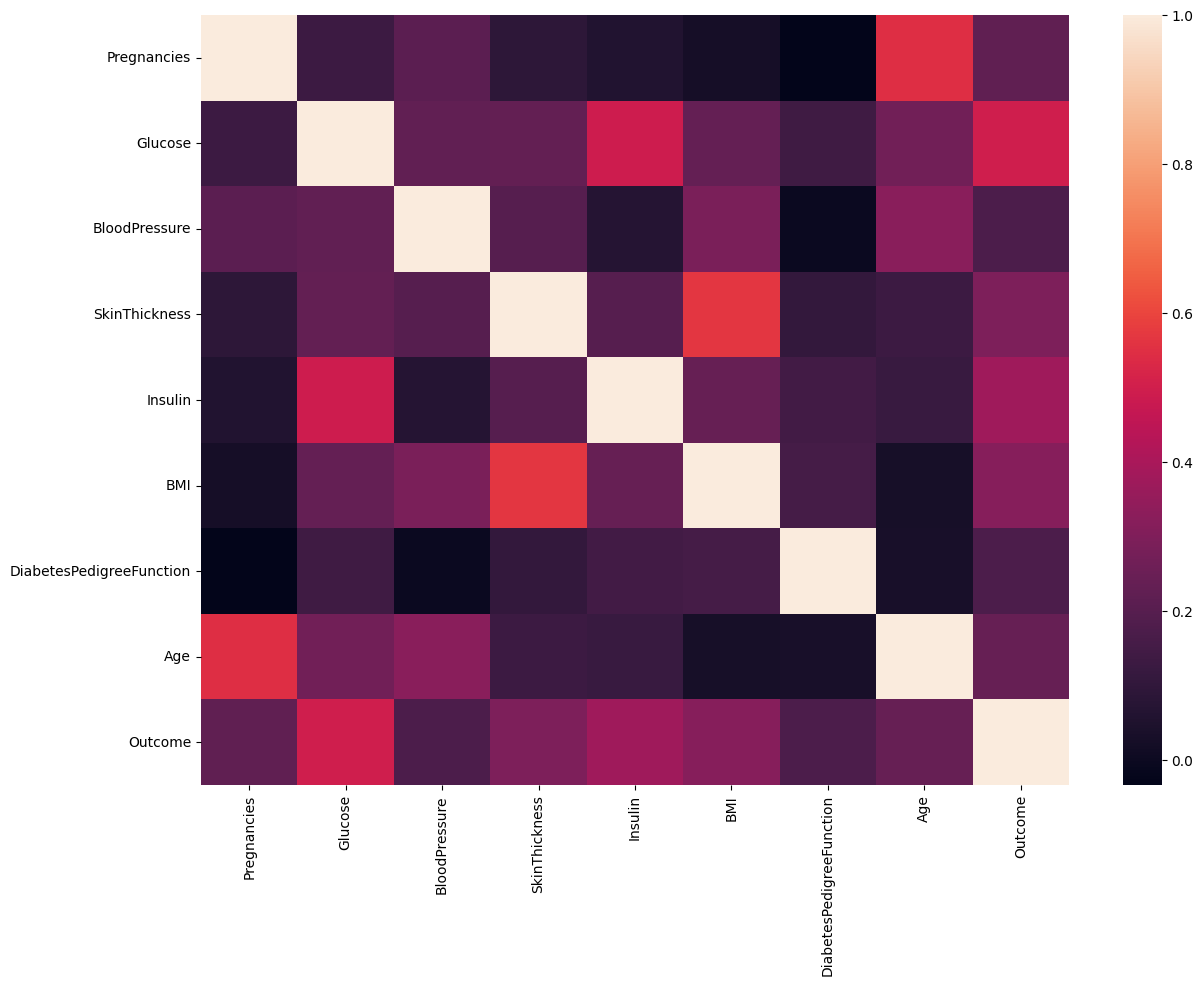

In [ ]:
# JUST CHECKING HOW COLUMNS ARE DIRECTLY RELATED TO EACH OTHER

plt.figure(figsize=(14,10))
sns.heatmap(df.corr())


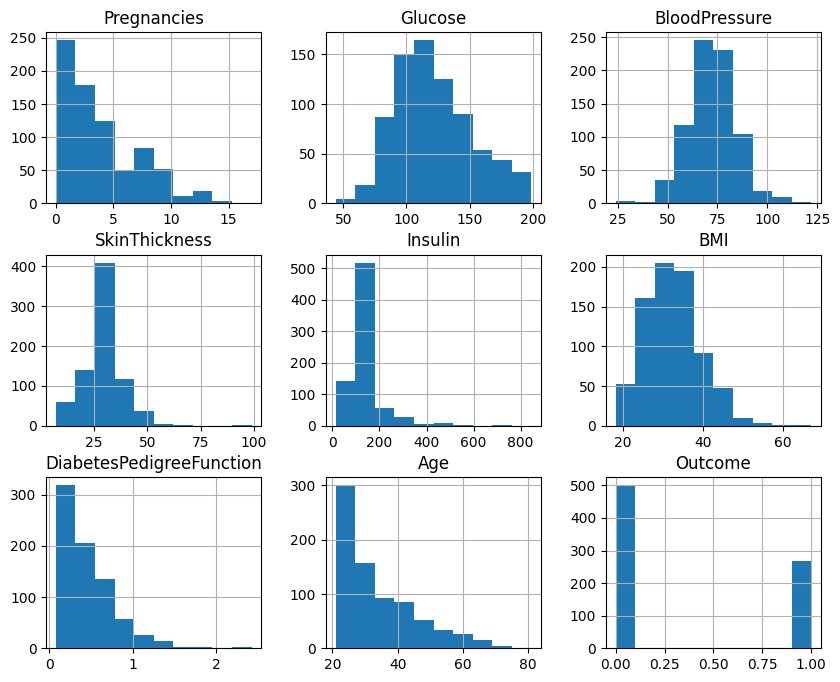

In [ ]:
# Histograms for data dist

df.hist(figsize=(10, 8))
plt.show()

**DATA SPLITING**

In [ ]:
# BEFORE SPLITING JUST CHECKING THE OVERVIEW OF SUCCESS / FAILURE CASES
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


In [ ]:
# SPLITING DATA

X = df.drop('Outcome', axis = 1)
y = df['Outcome']
X_train,X_test ,y_train ,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

**MODEL TRAINING:   THE ALGO WE WILL BE USING IS KNN**

*Before blindly jumping into it we have to make sure the below  points*

*   DATA SHOULD BE SCALED AS KNN IS DISTANCE BASED ALGO
*   FINDING CORRECT NUMBER OF NEIGHBOURS



In [ ]:

# SCALING DATA

scaler = StandardScaler()
Scaled_X_train = scaler.fit_transform(X_train)
Scaled_X_test = scaler.transform(X_test)


In [ ]:
# FINDIND BEST K VALUE


k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(Scaled_X_train, y_train)
    y_pred = model.predict(Scaled_X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)


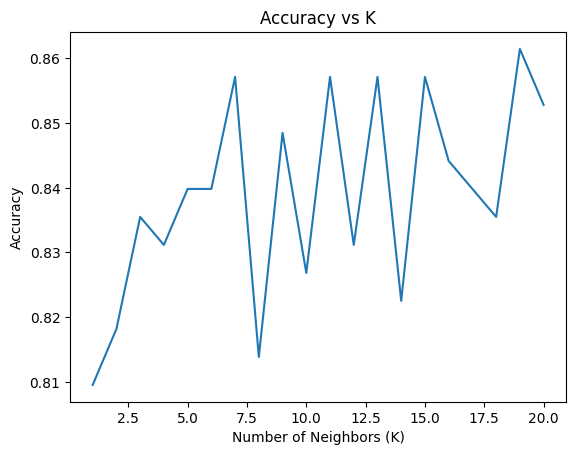

In [ ]:
# ViSUALIZING USING GRAPH

plt.plot(k_values, accuracies)
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()



**MAKING PIPELINE**

In [ ]:
# THIS STEP IS IMPORTANT WHEN WE ATTACH MODEL
# BY DOING THIS WE ARE MAKING SURE THE VALUES ARE SCALED WITH SAME SCALER BEFORE PRECESSING IT

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=20,
        weights="distance"
    ))
])

In [ ]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print("Accuracy:", accuracy * 100, "%")
print("Precision:", precision * 100, "%")

Accuracy: 87.01298701298701 %
Precision: 85.71428571428571 %


**VISUALIZING RESULTS**

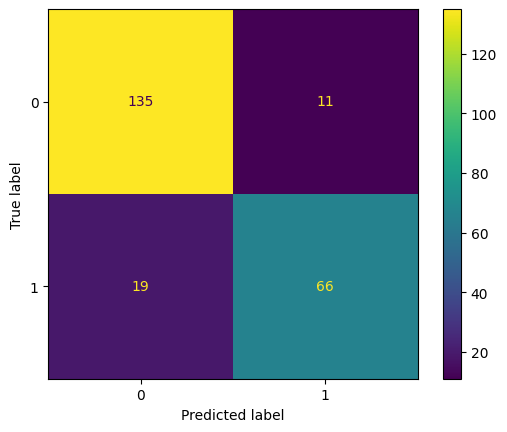

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

**SURFACE PLOT**

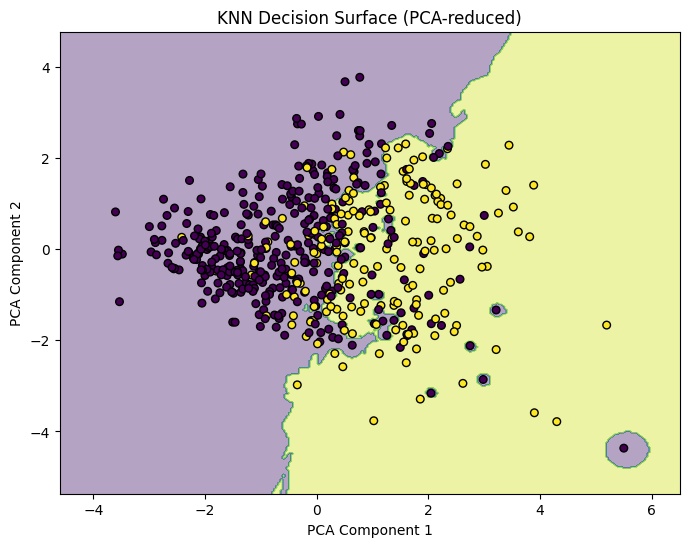

In [ ]:
# THiS TELLS YOU ABOUT HOW MODEL WILL BEHAVE TO CERTAIN POINTS

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(Scaled_X_train)
X_test_pca = pca.transform(Scaled_X_test)



knn_pca = KNeighborsClassifier(
    n_neighbors=20,
    weights='distance'
)

knn_pca.fit(X_train_pca, y_train)



x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision surface
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    edgecolor='k',
    s=30
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("KNN Decision Surface (PCA-reduced)")
plt.show()


**EXTRACTING MODEL**

In [ ]:
import pickle

# Save the model
with open('Diabetes_model1.pkl', 'wb') as file:
    pickle.dump(pipeline, file)

print("Model saved as Diabetes_model1.pkl")

Model saved as Diabetes_model1.pkl
